# Econ 390 - Lecture 16: APIs
Today we will go over Application Programming Interfaces (APIs), which are a very powerful tool but also one that must be used carefully. Turrell goes over it [here](https://aeturrell.github.io/coding-for-economists/data-extraction.html#obtaining-data-using-apis) and provides other methods of using APIs not covered in this class.

In [2]:
import pandas_datareader
# We have to install it!

## Installing a New Package
Open up "Anaconda Prompt" either by searching for an app on Windows (Windows Key + type in "Anaconda Prompt", clicking on it) or Mac Key + Space to open spotlight search, type "Terminal", and press return to open (you may need to hit Cmd + N to open a new window).

Assuming you only have one environment (if that's confusing to you - you only have one) it will always work on your base (and only) environment. 

To check if we have it downloaded type `conda list` and search for pandas-datareader. If you don't find it, that's because you don't have it installed!

To make sure we can actually download it this way, search for it by doing `conda search pandas-datareader`. This will show you any versions available to download here. By default it will download the newest version. To actually download, type `conda install pandas-datareader` and type `Y` when prompted.

Now it should be downloaded and you can type `exit` to close out and return here! Though you may need to restart the kernal using the kernal tab above to make use of the newly installed library.

pandas-datareader lets us interact with:
- FRED
- Quandl
- World Bank
- OECD
- Eurostat


In [3]:
# All of our imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web    

## FRED

In [15]:
# Downloading straight from FRED
codes = {"CPIAUCSL":"CPI", "CUSR0000SACL1E":"Core CPI"}
fred_CPI = web.DataReader(codes.keys(), 'fred', start="2010-01-01", end="2025-01-01")

fred_CPI

,CPIAUCSL,CUSR0000SACL1E
DATE,,
2010-01-01,217.488,144.114
2010-02-01,217.281,144.055
2010-03-01,217.353,143.879
2010-04-01,217.403,143.454
2010-05-01,217.290,143.304
...,...,...
2024-09-01,314.732,164.634
2024-10-01,315.631,164.698
2024-11-01,316.528,165.018


In [16]:
# Default Index?
fred_CPI.index

DatetimeIndex(['2010-01-01', '2010-02-01', '2010-03-01', '2010-04-01',
               '2010-05-01', '2010-06-01', '2010-07-01', '2010-08-01',
               '2010-09-01', '2010-10-01',
               ...
               '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
               '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01',
               '2024-12-01', '2025-01-01'],
              dtype='datetime64[ns]', name='DATE', length=181, freq=None)

In [17]:
# Rename variables and update to percent change
fred_CPI = fred_CPI.rename(columns=codes).pct_change(periods=12)*100
fred_CPI

,CPI,Core CPI
DATE,,
2010-01-01,NaN,NaN
2010-02-01,NaN,NaN
2010-03-01,NaN,NaN
2010-04-01,NaN,NaN
2010-05-01,NaN,NaN
...,...,...
2024-09-01,2.426483,-1.155153
2024-10-01,2.578844,-1.199182
2024-11-01,2.719472,-0.743441


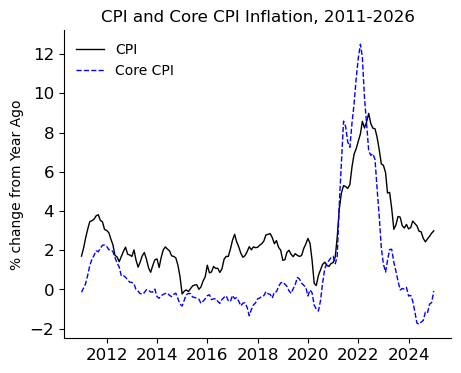

In [18]:
# Now we can easily plot with our paper stylesheet!
with plt.style.context("paper.mplstyle"):
    fig, ax = plt.subplots()
    ax.plot(fred_CPI.index, fred_CPI["CPI"], label="CPI")
    ax.plot(fred_CPI.index, fred_CPI["Core CPI"], label="Core CPI")
    ax.set_ylabel("% change from Year Ago")
    ax.set_title("CPI and Core CPI Inflation, 2011-2026")
    ax.legend()

plt.show()    

In [19]:
fred_CPI.index[-1].strftime("%Y")

'2025'

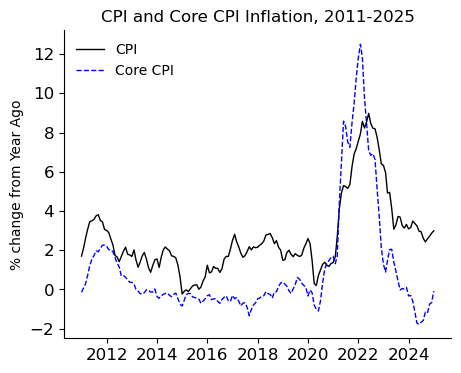

In [20]:
# Make it easily updateable
with plt.style.context("paper.mplstyle"):
    fig, ax = plt.subplots()
    ax.plot(fred_CPI.index, fred_CPI["CPI"], label="CPI")
    ax.plot(fred_CPI.index, fred_CPI["Core CPI"], label="Core CPI")
    ax.set_ylabel("% change from Year Ago")
    ax.set_title("CPI and Core CPI Inflation, 2011-{}".format(fred_CPI.index[-1].strftime("%Y")))
    ax.legend()

plt.show()    

## Stooq

In [21]:
# Dow Jones using Stooq
dowjones = web.DataReader("^DJI", "stooq")

dowjones

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-18,46913.93,46913.93,46193.06,46225.15,374362046.0
2026-03-17,47085.53,47428.12,46975.52,46993.26,365216860.0
2026-03-16,46707.40,47176.14,46707.40,46946.41,382305552.0
2026-03-13,46689.24,47123.99,46494.63,46558.47,343069925.0
2026-03-12,47242.52,47242.52,46662.23,46677.85,448812175.0
...,...,...,...,...,...
2021-03-26,32681.07,33098.83,32681.07,33072.88,440533072.0
2021-03-25,32346.81,32672.69,32071.41,32619.48,463916838.0
2021-03-24,32470.88,32787.99,32418.15,32420.06,456858883.0


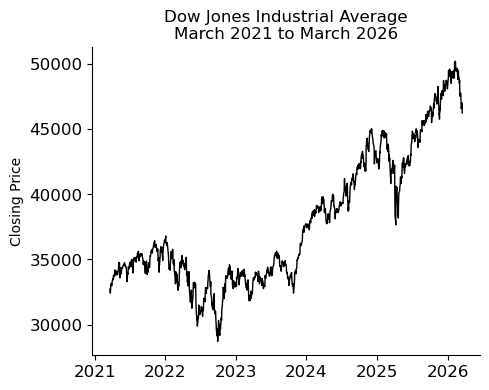

In [25]:
# Plot the Dow Jones
with plt.style.context("paper.mplstyle"):
    fig, ax = plt.subplots()
    ax.plot(dowjones.index, dowjones["Close"])
    ax.set_ylabel("Closing Price")
    ax.set_title("Dow Jones Industrial Average\n"
                 '{0} to {1}'.format(dowjones.index[-1].strftime("%B %Y"),
                                     dowjones.index[1].strftime("%B %Y")))

plt.show()

## World Bank

In [30]:
from pandas_datareader import wb
# Define parameters
indicators={"SL.AGR.EMPL.ZS":"Employment in Agriculture"}
countries = ["ALL"]
year = 2000

# Get data from World Bank
wb_AGEMP = wb.download(indicator=indicators.keys(),
                       country=countries,
                       start=year,
                       end=year)

wb_AGEMP

C:\Users\micha\AppData\Local\Temp\ipykernel_22184\805732853.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  wb_AGEMP = wb.download(indicator=indicators.keys(),


,,SL.AGR.EMPL.ZS
country,year,
Africa Eastern and Southern,2000,61.819233
Africa Western and Central,2000,57.017447
Arab World,2000,28.764743
Caribbean small states,2000,12.877604
Central Europe and the Baltics,2000,17.877201
...,...,...
Virgin Islands (U.S.),2000,2.941990
West Bank and Gaza,2000,12.481793
"Yemen, Rep.",2000,54.769359


In [31]:
# Rename
wb_AGEMP = wb_AGEMP.rename(columns=indicators)
wb_AGEMP

,,Employment in Agriculture
country,year,
Africa Eastern and Southern,2000,61.819233
Africa Western and Central,2000,57.017447
Arab World,2000,28.764743
Caribbean small states,2000,12.877604
Central Europe and the Baltics,2000,17.877201
...,...,...
Virgin Islands (U.S.),2000,2.941990
West Bank and Gaza,2000,12.481793
"Yemen, Rep.",2000,54.769359


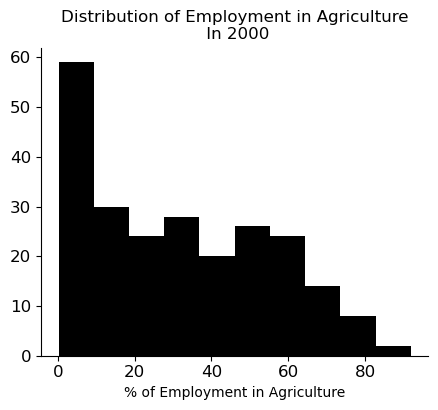

In [32]:
# Using our paper stylesheet
with plt.style.context("paper.mplstyle"):
    # Histogram of employment in agriculture
    fig, ax = plt.subplots()
    ax.hist(wb_AGEMP["Employment in Agriculture"])
    ax.set(xlabel="% of Employment in Agriculture",
          title="Distribution of Employment in Agriculture\n In {}".format(year))

plt.show()

In [39]:
# What is the US?
wb_AGEMP.loc["United States"]

,Employment in Agriculture
year,
2000,2.396546


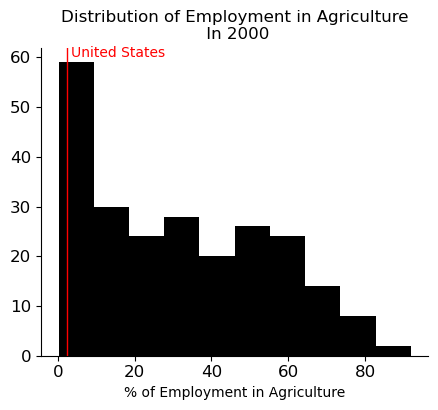

In [42]:
# Highlight the US
with plt.style.context("paper.mplstyle"):
    # Histogram of employment in agriculture
    fig, ax = plt.subplots()
    ax.hist(wb_AGEMP["Employment in Agriculture"])
    ax.set(xlabel="% of Employment in Agriculture",
          title="Distribution of Employment in Agriculture\n In {}".format(year))
    ax.axvline(x = 2.4, color="red")
    ax.text(3.5, 60,"United States", color="red")

plt.show()

## Practice - FRED
1. Go to the FRED website and find the series for "Infra-Annual Labor Statistics: Working-Age Population Total: From 15 to 64 Years for United States" and "Real Gross Domestic Product"
2. First modify the code below plot the Real GDP in the U.S. from 1960-Today. What are the units? Do we need a legend anymore?
3. Modify the code below to calculate and plot the Real GDP per Capita in 2017 dollars.

In [ ]:
codes = {'CPIAUCSL' : 'CPI', 'CPILFESL' :'Core CPI'}
fred_CPI = web.DataReader(codes.keys(), 'fred', start='2010-01-01')
fred_CPI = fred_CPI.rename(columns=codes).pct_change(periods=12)*100

# Now we can easily plot with our paper stylesheet!
with plt.style.context('paper.mplstyle'):
    fig, ax = plt.subplots()
    ax.plot(fred_CPI.index, fred_CPI['CPI'], label='CPI')
    ax.plot(fred_CPI.index, fred_CPI['Core CPI'], label='Core CPI')
    ax.set_ylabel('% Change from Year Ago')
    ax.set_title('CPI and Core CPI Inflation, 2011-{}'.format(fred.index[-1].strftime('%Y')))
    ax.legend()

plt.show()

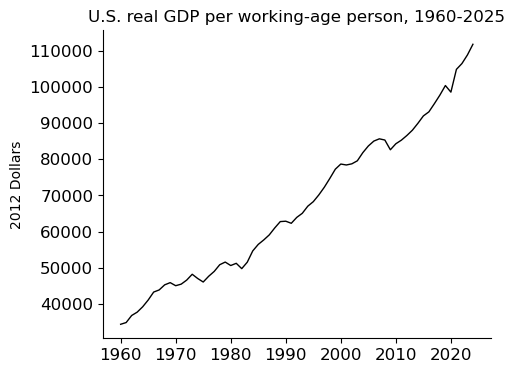

In [44]:
# Results
codes = {'LFWA64TTUSA647N': 'working age pop', 'GDPCA': 'gdp'}
fred = web.DataReader(codes.keys(), 'fred', start='1960-01-01')
fred = fred.rename(columns=codes)           
fred['gdp_per_capita'] = fred['gdp']*1000000000/fred['working age pop']

with plt.style.context('paper.mplstyle'):
    fig, ax = plt.subplots()
    ax.plot(fred.index, fred['gdp_per_capita'])
    ax.set_ylabel('2012 Dollars')
    ax.set_title('U.S. real GDP per working-age person, 1960-{}'.format(fred.index[-1].strftime('%Y')))

plt.show()